## Model Comparison

In [1]:
import pandas as pd

results = pd.DataFrame([
    {
        "Model": "Simple RNN",
        "Accuracy": 0.7545,
        "Precision": 0.7668,
        "Recall": 0.7314,
        "F1": 0.7487,
        "ROC-AUC": 0.8202,
    },
    {
        "Model": "LSTM",
        "Accuracy": 0.8373,
        "Precision": 0.8191,
        "Recall": 0.8659,
        "F1": 0.8418,
        "ROC-AUC": 0.9124,
    },
    {
        "Model": "BiLSTM",
        "Accuracy": 0.8542,
        "Precision": 0.8641,
        "Recall": 0.8406,
        "F1": 0.8522,
        "ROC-AUC": 0.9324,
    },
    {
        "Model": "Transformer",
        "Accuracy": 0.8568,
        "Precision": 0.8621,
        "Recall": 0.8494,
        "F1": 0.8557,
        "ROC-AUC": 0.9333,
    },
])

results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Simple RNN,0.7545,0.7668,0.7314,0.7487,0.8202
1,LSTM,0.8373,0.8191,0.8659,0.8418,0.9124
2,BiLSTM,0.8542,0.8641,0.8406,0.8522,0.9324
3,Transformer,0.8568,0.8621,0.8494,0.8557,0.9333


### Calculate the improvement

In [2]:
baseline = results.iloc[0]
best_model = results.iloc[-1]

print("RNN → Transformer")
print(
    f"Accuracy improvement : "
    f"{(best_model['Accuracy'] - baseline['Accuracy']) * 100:.2f} percentage points"
)

print(
    f"F1 improvement       : "
    f"{(best_model['F1'] - baseline['F1']) * 100:.2f} percentage points"
)

print(
    f"ROC-AUC improvement   : "
    f"{(best_model['ROC-AUC'] - baseline['ROC-AUC']) * 100:.2f} percentage points"
)

RNN → Transformer
Accuracy improvement : 10.23 percentage points
F1 improvement       : 10.70 percentage points
ROC-AUC improvement   : 11.31 percentage points


In [3]:
bilstm = results[results["Model"] == "BiLSTM"].iloc[0]
transformer = results[results["Model"] == "Transformer"].iloc[0]

print("BiLSTM → Transformer")

for metric in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]:
    improvement = (
        transformer[metric] - bilstm[metric]
    ) * 100

    print(f"{metric:10s}: {improvement:+.2f} percentage points")

BiLSTM → Transformer
Accuracy  : +0.26 percentage points
Precision : -0.20 percentage points
Recall    : +0.88 percentage points
F1        : +0.35 percentage points
ROC-AUC   : +0.09 percentage points


## FINAL RESULT

In [2]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Simple RNN",
        "LSTM",
        "BiLSTM",
        "Transformer",
    ],
    "Accuracy": [
        0.7545,
        0.8373,
        0.8542,
        0.8458,
    ],
    "Precision": [
        0.7668,
        0.8191,
        0.8641,
        0.8470,
    ],
    "Recall": [
        0.7314,
        0.8659,
        0.8406,
        0.8441,
    ],
    "F1": [
        0.7487,
        0.8418,
        0.8522,
        0.8455,
    ],
    "ROC-AUC": [
        0.8202,
        0.9124,
        0.9324,
        0.9261,
    ],
})

results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Simple RNN,0.7545,0.7668,0.7314,0.7487,0.8202
1,LSTM,0.8373,0.8191,0.8659,0.8418,0.9124
2,BiLSTM,0.8542,0.8641,0.8406,0.8522,0.9324
3,Transformer,0.8458,0.8470,0.8441,0.8455,0.9261


In [3]:
results.set_index("Model")

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Simple RNN,0.7545,0.7668,0.7314,0.7487,0.8202
LSTM,0.8373,0.8191,0.8659,0.8418,0.9124
BiLSTM,0.8542,0.8641,0.8406,0.8522,0.9324
Transformer,0.8458,0.8470,0.8441,0.8455,0.9261


In [5]:
import os

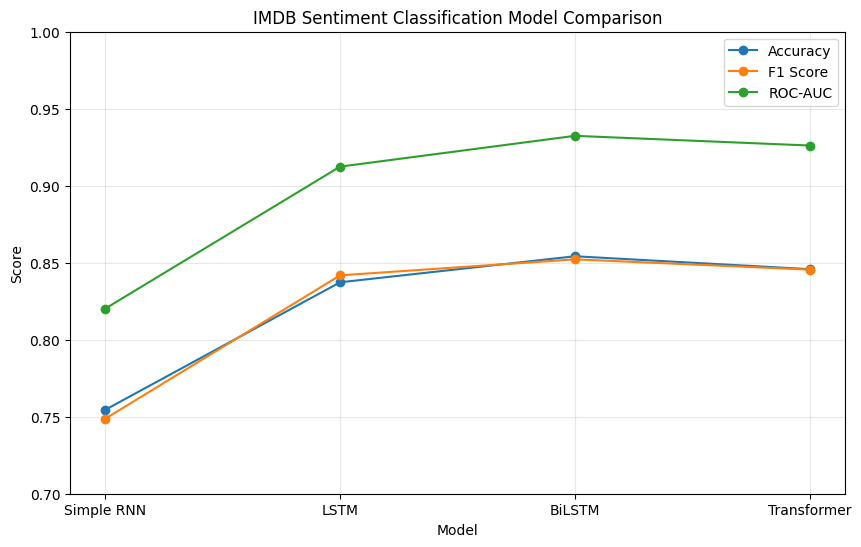

In [6]:
## visualize the comparision

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    results["Model"],
    results["Accuracy"],
    marker="o",
    label="Accuracy",
)

plt.plot(
    results["Model"],
    results["F1"],
    marker="o",
    label="F1 Score",
)

plt.plot(
    results["Model"],
    results["ROC-AUC"],
    marker="o",
    label="ROC-AUC",
)

plt.xlabel("Model")
plt.ylabel("Score")
plt.title("IMDB Sentiment Classification Model Comparison")
plt.ylim(0.70, 1.00)
plt.legend()
plt.grid(True, alpha=0.3)

save_dir = "plots/result/"
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, "result_comparison.png"), dpi=300, bbox_inches="tight")

plt.show()